In [ ]:
#import sys
#!{sys.executable} -m pip install pandas matplotlib seaborn

In [13]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [14]:
import os
print(os.getcwd())

c:\Users\yjain\OneDrive\Documents\portfolio\Project3-Python-Churn


In [25]:
# Load dataset
df = pd.read_csv('BankChurners.csv')

# Quick first look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (10127, 23)

First 5 rows:


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [16]:
print(df.columns.tolist())

['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']


In [17]:
print (df.dtypes)

CLIENTNUM                                                                                                                               int64
Attrition_Flag                                                                                                                            str
Customer_Age                                                                                                                            int64
Gender                                                                                                                                    str
Dependent_count                                                                                                                         int64
Education_Level                                                                                                                           str
Marital_Status                                                                                                                            str
Income

In [18]:
print(df.isnull().sum())

CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

In [19]:
# Drop unnecessary columns
df = df.drop(columns=[
    'CLIENTNUM',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
])

# Confirm shape after dropping
print("Shape after cleaning:", df.shape)
print("\nRemaining columns:")
print(df.columns.tolist())

Shape after cleaning: (10127, 20)

Remaining columns:
['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


Churn Counts:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Churn Percentage:
Attrition_Flag
Existing Customer    83.93
Attrited Customer    16.07
Name: proportion, dtype: float64


C:\Users\yjain\AppData\Local\Temp\ipykernel_19404\3729130678.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Attrition_Flag', palette='Set2')


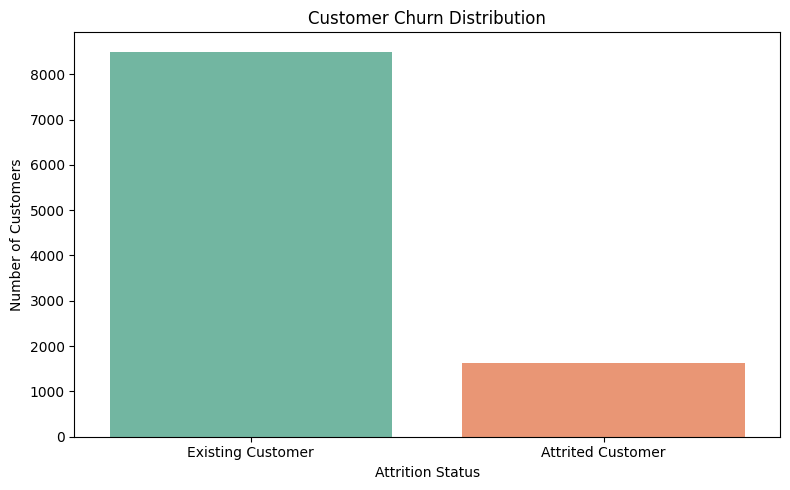

In [20]:
# Check churn distribution
churn_counts = df['Attrition_Flag'].value_counts()
churn_pct = df['Attrition_Flag'].value_counts(normalize=True) * 100

print("Churn Counts:")
print(churn_counts)
print("\nChurn Percentage:")
print(churn_pct.round(2))

# Visualize
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Attrition_Flag', palette='Set2')
plt.title('Customer Churn Distribution')
plt.xlabel('Attrition Status')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

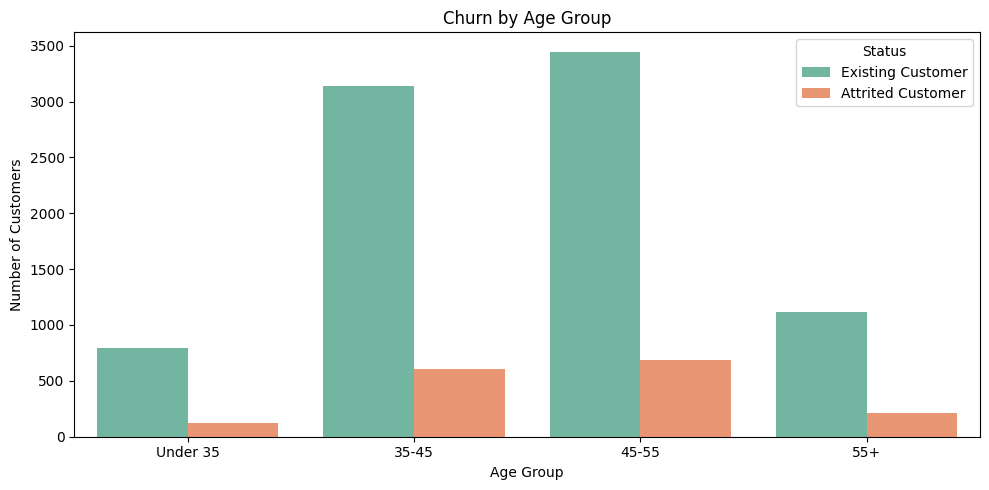

In [21]:
# Churn by age group
df['Age_Group'] = pd.cut(df['Customer_Age'], 
                          bins=[0, 35, 45, 55, 100],
                          labels=['Under 35', '35-45', '45-55', '55+'])

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Age_Group', hue='Attrition_Flag', palette='Set2')
plt.title('Churn by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

Churn Rate by Age Group:
Age_Group
Under 35    13.28
35-45       16.19
45-55       16.64
55+         15.85
Name: Attrition_Flag, dtype: float64


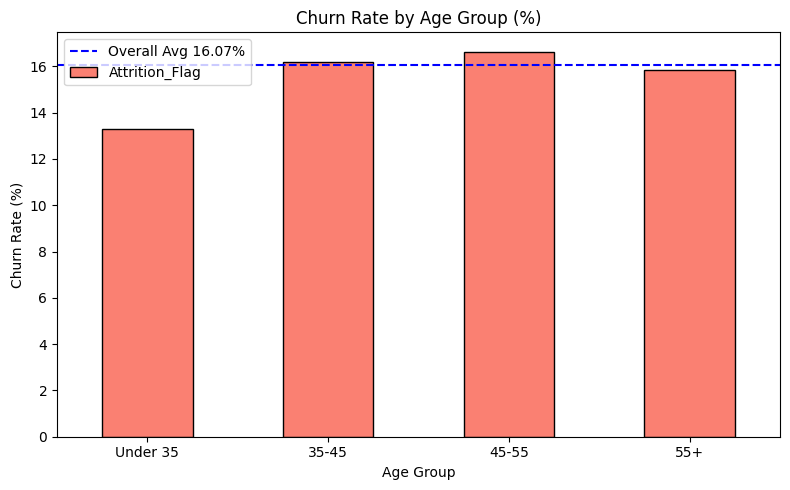

In [22]:
# Churn RATE by age group (not just count)
churn_rate_age = df.groupby('Age_Group')['Attrition_Flag'].apply(
    lambda x: (x == 'Attrited Customer').sum() / len(x) * 100
).round(2)

print("Churn Rate by Age Group:")
print(churn_rate_age)

# Visualize
plt.figure(figsize=(8, 5))
churn_rate_age.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Churn Rate by Age Group (%)')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.axhline(y=16.07, color='blue', linestyle='--', label='Overall Avg 16.07%')
plt.legend()
plt.tight_layout()
plt.show()

Churn Rate by Gender:
Gender
F    17.36
M    14.62
Name: Attrition_Flag, dtype: float64


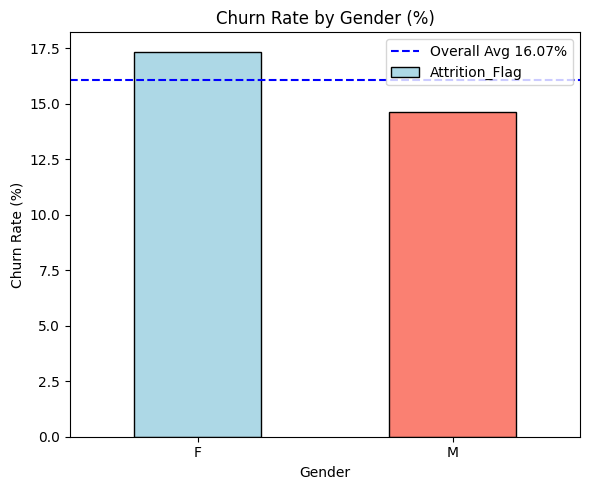

In [23]:
# Churn rate by gender
churn_rate_gender = df.groupby('Gender')['Attrition_Flag'].apply(
    lambda x: (x == 'Attrited Customer').sum() / len(x) * 100
).round(2)

print("Churn Rate by Gender:")
print(churn_rate_gender)

# Visualize
plt.figure(figsize=(6, 5))
churn_rate_gender.plot(kind='bar', color=['lightblue', 'salmon'], edgecolor='black')
plt.title('Churn Rate by Gender (%)')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.axhline(y=16.07, color='blue', linestyle='--', label='Overall Avg 16.07%')
plt.legend()
plt.tight_layout()
plt.show()

Churn Rate by Income Category:
Income_Category
$120K +           17.33
Less than $40K    17.19
Unknown           16.82
$80K - $120K      15.77
$40K - $60K       15.14
$60K - $80K       13.48
Name: Attrition_Flag, dtype: float64


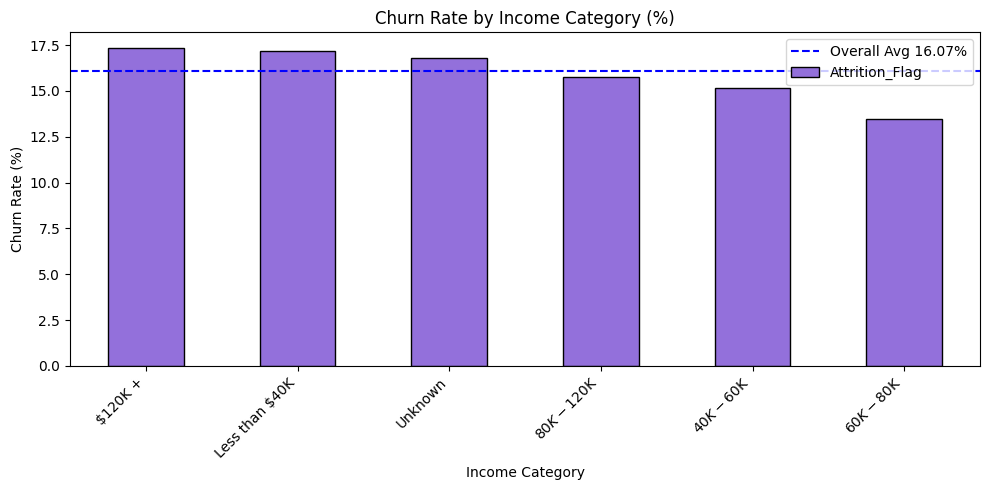

In [24]:
# Churn rate by income category
churn_rate_income = df.groupby('Income_Category')['Attrition_Flag'].apply(
    lambda x: (x == 'Attrited Customer').sum() / len(x) * 100
).round(2).sort_values(ascending=False)

print("Churn Rate by Income Category:")
print(churn_rate_income)

# Visualize
plt.figure(figsize=(10, 5))
churn_rate_income.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Churn Rate by Income Category (%)')
plt.xlabel('Income Category')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=16.07, color='blue', linestyle='--', label='Overall Avg 16.07%')
plt.legend()
plt.tight_layout()
plt.show()